# Model Evaluation And Refinement


In [2]:
import numpy as np  
import pandas as pd   
import matplotlib.pyplot as plt  
import warnings 
import seaborn as sns  


**Traing And Testing**

In [3]:
air = pd.read_csv('airlines_flights_data.csv')
air.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
air.drop(['index'],axis=1,inplace=True)
air.head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
df = air._get_numeric_data()
df.head()

,duration,days_left,price
0,2.17,1,5953
1,2.33,1,5953
2,2.17,1,5956
3,2.25,1,5955
4,2.33,1,5955


In [6]:
def DistributionPlot(RedFunction, BlueFunction,RedName,BlueName,Title):
    width = 12
    height = 10
    
    ax1 = sns.kdeplot(RedFunction, color='r', label=RedName)
    ax2 = sns.kdeplot(BlueFunction, color='b', label=BlueName, ax=ax1)

    plt.title('Title')
    plt.xlabel('price')
    plt.ylabel('class')
    plt.show()
    plt.close()

In [7]:
def pollyplot(x_train,x_test,y_train,y_test,lr,poly_transform):

    width = 12
    height = 10
    plt.figure(figure=(width,height))

    xmax = max([x_train.values.max(),x_test.values.max()])
    xmin = min([x_train.values.min(),x_test.values.min()])

    x = np.arange(xmin,xmax,0.1)

    plt.plot(x_train,y_train,'ro',label='Training Data')
    plt.plot(x_test,y_test,'go',label='Test Data')
    plt.plot(x,lr.predict(poly_transform.fit_transform(x.reshape(-1,1))),label='Predicted Function')
    plt.ylim([-10000,60000])
    plt.ylabel('Price')
    plt.legend()

In [8]:
y_data =df['price']
y_data

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [9]:
x_data = df.drop('price',axis=1)
x_data

,duration,days_left
0,2.17,1
1,2.33,1
2,2.17,1
3,2.25,1
4,2.33,1
...,...,...
300148,10.08,49
300149,10.42,49
300150,13.83,49
300151,10.00,49


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x_data,y_data,test_size=0.10,random_state=1)

In [12]:
print("Number of testing sample:",x_test.shape[0])
print("Number of training sample:",x_train.shape[0])

Number of testing sample: 30016
Number of training sample: 270137


In [13]:
airs =np.array(df)
airs

array([[2.1700e+00, 1.0000e+00, 5.9530e+03],
       [2.3300e+00, 1.0000e+00, 5.9530e+03],
       [2.1700e+00, 1.0000e+00, 5.9560e+03],
       ...,
       [1.3830e+01, 4.9000e+01, 7.9099e+04],
       [1.0000e+01, 4.9000e+01, 8.1585e+04],
       [1.0080e+01, 4.9000e+01, 8.1585e+04]])

In [14]:
df.head()

,duration,days_left,price
0,2.17,1,5953
1,2.33,1,5953
2,2.17,1,5956
3,2.25,1,5955
4,2.33,1,5955


In [15]:
df.sample()

,duration,days_left,price
247649,13.58,37,50361


In [16]:
y_data= df['duration']
x_data=air.drop('arrival_time',axis=1)

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=0.10,random_state=1)

In [18]:
print('Number of testing sample:',x_test.shape[0])
print('Number of training sample:',x_train.shape[0])

Number of testing sample: 30016
Number of training sample: 270137


In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lre = LinearRegression() 

In [21]:
lre.fit(x_train[['price']],y_train)

LinearRegression()

In [22]:
lre.score(x_test[['price']],y_test)

0.04333702435026854

In [23]:
lre.score(x_train[['price']],y_train)

0.041511195667062184

In [24]:
x_train1,x_test1,y_train1,y_test1 = train_test_split(x_data,y_data,test_size=0.4,random_state=0)

In [25]:
lre.fit(x_train1[['price']],y_train1)
lre.score(x_test1[['price']],y_test1)

0.04356207123603861

Cross-Validation Score

In [26]:
from sklearn.model_selection import  cross_val_score

In [27]:
Rcross = cross_val_score(lre, x_data[['price']],y_data,cv=4)

Rcross

array([ 0.01135317,  0.00924612,  0.02008649, -0.00809625])

In [28]:
print('The mean of the avrage:', Rcross.mean(),'And the standard diviation is:',Rcross.std())

The mean of the avrage: 0.008147380560996176 And the standard diviation is: 0.010221083452985532


In [29]:
-1 * cross_val_score(lre,x_data[['duration']],y_data,cv=4,scoring='neg_mean_squared_error')

array([1.72173671e-29, 2.72582993e-26, 1.32209671e-27, 2.97365026e-27])

In [30]:
Rcross.mean()

0.008147380560996176

In [31]:
from sklearn.model_selection import cross_val_predict

In [32]:
yhat = cross_val_predict(lre,x_data[['price']],y_data, cv=4)
yhat

array([11.46845551, 11.46845551, 11.46863022, ..., 17.64665903,
       17.86216482, 17.86216482])

In [33]:
air.value_counts('airline')

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

**Overfitting , Underfitting and Model Selection**

In [34]:
lr = LinearRegression()
lr.fit(x_train[['duration','price']],y_train)

LinearRegression()

In [35]:
yhat_train = lr.predict(x_train[['duration','price']])
yhat_train[0:5]

array([22.17, 27.58,  2.5 , 29.92,  2.42])

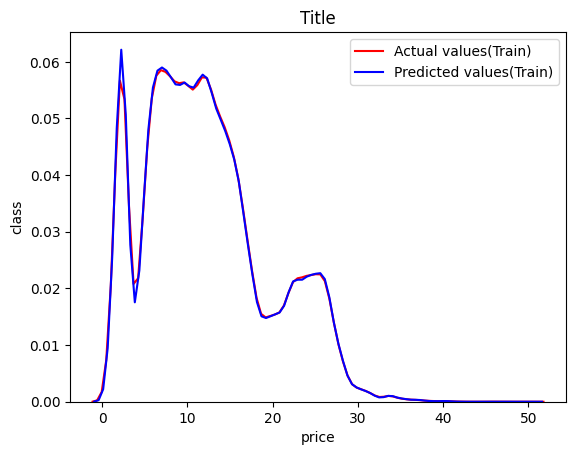

In [80]:
title='Distribution plot of predicted value using training Data Vs training Data Distribution'
DistributionPlot(y_train,yhat_train,'Actual values(Train)',"Predicted values(Train)",'title')

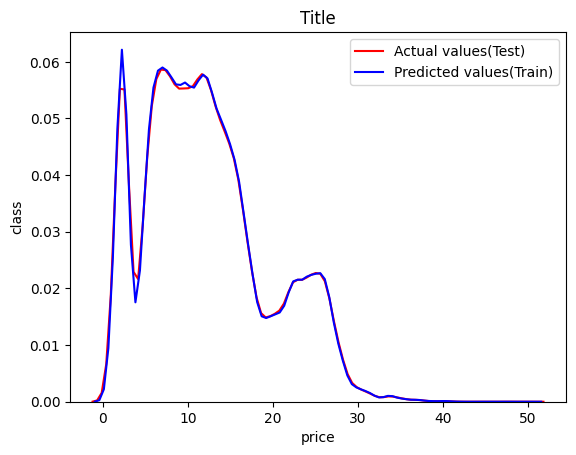

In [81]:
Title = 'Distribution plot of predicted value using testing Data Vs testing Data Distribution'
DistributionPlot(y_test,yhat_train,'Actual values(Test)',"Predicted values(Train)",Title)

In [38]:
from sklearn.preprocessing import PolynomialFeatures

In [39]:
x_train ,x_test,y_train, y_test = train_test_split(x_data,y_data,test_size=0.45,random_state=0)

In [40]:
pr = PolynomialFeatures(degree=5)
x_train_pr = pr.fit_transform(x_train[['price']])
x_test_pr = pr.fit_transform(x_test[['price']])
pr

PolynomialFeatures(degree=5)

In [41]:
poly = LinearRegression()
poly.fit(x_train_pr,y_train)

LinearRegression()

In [42]:
yhat = poly.predict(x_test_pr)
yhat[0:5]

array([11.39001684, 14.34585064, 11.30659002, 11.27336113, 11.28123321])

In [43]:
print('Predicted values:',yhat[0:4])
print('True values:',y_test[0:4].values)

Predicted values: [11.39001684 14.34585064 11.30659002 11.27336113]
True values: [27.5   6.92  2.25  2.83]


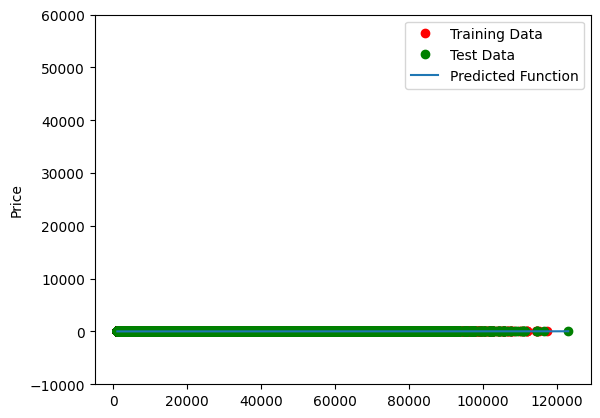

In [44]:
pollyplot(x_train['price'],x_test['price'],y_train,y_test,poly,pr)

In [45]:
poly.score(x_train_pr,y_train)

0.037923231480837316

In [46]:
poly.score(x_test_pr,y_test)

0.04014753738150989

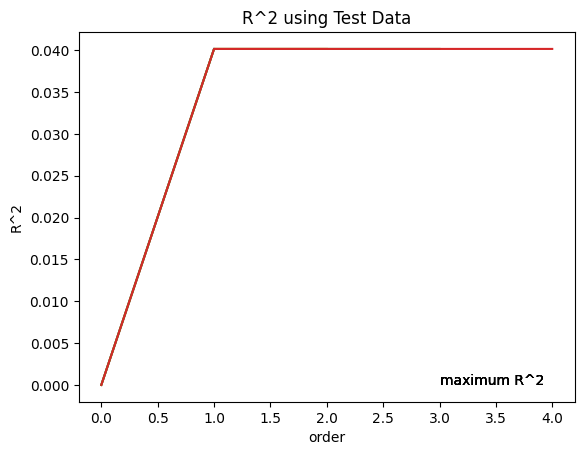

In [47]:
Rsqu_test = [0]
order =[1,2,3,4]

for n in order:
    pr = PolynomialFeatures(degree=5)
    x_train_pr = pr.fit_transform(x_train[['price']])
    x_test_pr = pr.fit_transform(x_test[['price']])

    lr.fit(x_train_pr,y_train)

    Rsqu_test.append(lr.score(x_test_pr,y_test))

    plt.plot(Rsqu_test)
    plt.xlabel('order')
    plt.ylabel('R^2')
    plt.title('R^2 using Test Data')
    plt.text(3,0.00,'maximum R^2')

In [48]:
def f(order,test_data):
    x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=test_data,random_state=0)

    prr = PolynomialFeatures(degree=order)
    x_train_pr = prr.fit_transform(x_train[['price']])
    x_text_pr = prr.fit_transform(x_test[['price']])

    poly = LinearRegression()
    poly.fit(x_train_pr,y_train)
    pollyplot(x_train['price'],x_test['price'],y_train,y_test,poly,prr)

    interface(f,order=(0,6,1),test_data=[0.05,0.95,0.5])

    

In [49]:
pr1 = PolynomialFeatures(degree=2)

In [50]:
x_train_pr1 = pr1.fit_transform(x_train[['duration','days_left','price']])
x_test_pr1 = pr1.fit_transform(x_test[['duration','days_left','price']])

In [51]:
x_train_pr1.shape

(165084, 10)

In [52]:
poly1 = LinearRegression().fit(x_test_pr1,y_test)
poly1

LinearRegression()

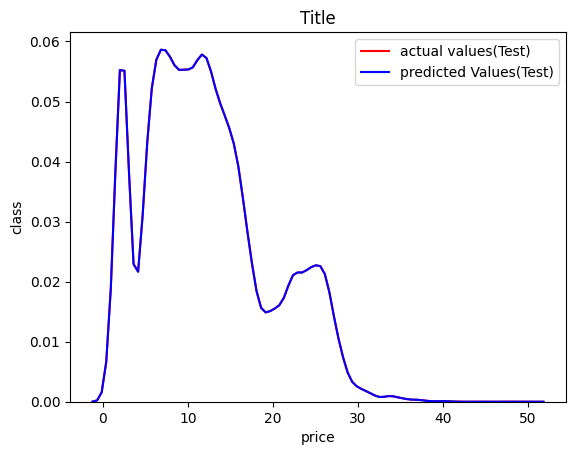

In [53]:
yhat_test1 = poly1.predict(x_test_pr1)
title = 'Distribution Plot od predicted value using Test data Vs Data Distribution of Test Data'
DistributionPlot(y_test,yhat_test1,"actual values(Test)",'predicted Values(Test)',title)

**Ridge Regression**

In [54]:
pf = PolynomialFeatures(degree=2)

x_train_pr1 = pf.fit_transform(x_train[['duration','days_left','price']])
x_test_pr1 = pf.fit_transform(x_test[['duration','days_left','price']])

In [55]:
from sklearn.linear_model import Ridge

In [56]:
RidgeModel = Ridge(alpha=1)

In [57]:
RidgeModel.fit(x_train_pr,y_train)

c:\Users\91830\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.63934e-53): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge(alpha=1)

In [58]:
yhaat = RidgeModel.predict(x_test_pr)
yhaat

array([14.16355092, 15.36167963, 12.46517646, ..., 10.39637796,
       11.88807284, 13.16404694])

In [59]:
print('predicted:',yhaat[0:5])
print('test set :',y_test[0:5].values)

predicted: [14.16355092 15.36167963 12.46517646  7.583455   10.25139254]
test set : [27.5   6.92  2.25  2.83 25.75]


In [60]:
from tqdm import tqdm

In [61]:
rsqu_test= []
rsqu_train= []
dummy1 =[]
alpha = 10* np.array(range(0,1000))
pbar = tqdm(alpha)

for alpha in pbar:
    RidgeModel = Ridge(alpha=alpha)
    RidgeModel.fit(x_train_pr1,y_train)

    test_score , train_score = RidgeModel.score(x_test_pr1,y_test),RidgeModel.score(x_train_pr1,y_train)

    pbar.set_postfix({'Test score':test_score,'Train score': train_score})
    
    rsqu_test.append(test_score)
    rsqu_train.append(train_score)

  0%|          | 1/1000 [00:00<02:48,  5.93it/s, Test score=1, Train score=1]c:\Users\91830\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.5617e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
  0%|          | 1/1000 [00:00<02:48,  5.93it/s, Test score=1, Train score=1]

c:\Users\91830\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=5.12339e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
  0%|          | 3/1000 [00:00<01:53,  8.75it/s, Test score=1, Train score=1]c:\Users\91830\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=7.68509e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
  0%|          | 3/1000 [00:00<01:53,  8.75it/s, Test score=1, Train score=1]c:\Users\91830\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.02468e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
  0%|          | 5/1000 [00:00<01:28, 11.22it/s, Test score=1, 

**Grid Search**

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
parameter1 =[{'alpha':[0.001,0.1,10,100,1000,10000,100000]}]
parameter1

[{'alpha': [0.001, 0.1, 10, 100, 1000, 10000, 100000]}]

In [64]:
RR = Ridge()
RR

Ridge()

In [65]:
grid = GridSearchCV(RR,parameter1,cv=4)

In [66]:
grid.fit(x_data[['duration','days_left','price']],y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 10, 100, 1000, 10000, 100000]}])

In [67]:
brr = grid.best_estimator_
brr

Ridge(alpha=0.001)

In [68]:
brr.score(x_test[['duration','days_left','price']],y_test)

1.0

In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()

In [71]:
x_scaler = scaler.fit_transform(x_data[['duration','days_left','price']])
parameter =[{'alpha':[0.001,0.1,10,100,1000,10000,100000]}]

In [72]:
grid1 = GridSearchCV(Ridge(),parameter,cv=10)
grid1.fit(x_scaler,y_data)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 10, 100, 1000, 10000, 100000]}])

In [73]:
best_model = grid1.best_estimator_
best_alpha= grid1.best_params_['alpha']
best_alpha

0.001

In [86]:
corr= air.corr(numeric_only=True).round(2)
print(corr.to_string())

           duration  days_left  price
duration       1.00      -0.04   0.20
days_left     -0.04       1.00  -0.09
price          0.20      -0.09   1.00


In [130]:
group = corr.pivot(index='price',columns='duration')


C:\Users\91830\AppData\Local\Temp\ipykernel_6980\826680807.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  fig.colorbar(im)


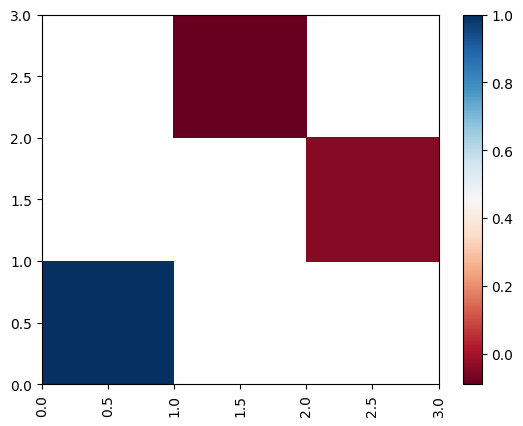

In [134]:
fig,ax = plt.subplots()
im = ax.pcolor(group,cmap='RdBu')

row = group.columns.levels[1]
col = group.index

ax.set_xticks(np.arange(group.shape[1])+0.5,minor=True)
ax.set_yticks(np.arange(group.shape[0])+0.5,minor=True)

ax.set_xticklabels(row,minor=True)
ax.set_yticklabels(col,minor=True)
plt.xticks(rotation=90)
fig.colorbar(im)
plt.show()

# End the project